The first exercise of this homework contains small unrelated questions on code. The final exam may contain similar questions, in which you will be asked to analyze or correct a piece of code. 

The second exercise uses a physics dataset on which we perform linear classification.

In [4]:
# don't forget to run this command before running the script!

import pandas as pd
import numpy as np
np.random.seed(0)

import sklearn.model_selection as ms
import sklearn.linear_model as lm
import sklearn.preprocessing as pp
import matplotlib.pyplot as plt

## Exercise 1 

In [5]:
def loss(x, y, w, l):
    # x is a n \times d matrix, y is a vector
    return np.sum((y - x.dot(w))**2 / 2) + (l / 2) * np.sum(np.abs(w))

**Question 1** What loss, seen in class, is computed by the function `loss` ?  Explain in what contexts it is used, compared to other losses.

_Answer_ : This is the LASSO loss. This error can be used in features selection as it tends to drive some weights to 0 or also if the user is looking for a sparse solution. Unlike the OLS (Ordinary Least Square), the LASSO error got a regularization term, which reduce the risk of over fitting for high dimensional problems. To compare with the Ridge error, even if the latter tends to minimize the weights, they remains non-zero, thus the problem dimension is not reduced.

**NOTE**
Common mistake was to forget what the 'other losses' are, and to compare to them.

In [1]:
# before
def ridge_estimator(x, y, l):
    n, d = x.shape
    return (x.T @ x + l * np.eye(d)) @ x.T @ y

# fixed 
def ridge_estimator(x, y, l):
    n, d = x.shape
    return np.linalg.inv(x.T @ x + l * np.eye(d)) @ x.T @ y

**Question 2** We want the function `ridge_estimator` to compute the estimator that minimizes the Ridge loss. Is there any mistake in this code ? If yes, fix it.

_Answer_ : Yes, you need to invert the first term.

In [7]:
def gradient_descent(x, y):
    # compute an estimator using gradient descent
    n, d = x.shape
    w = np.zeros(d)
    tolerance = 1e-3
    diff = np.inf

    eta = 0.1
    
    while diff > tolerance:
        w_old = np.copy(w)

        indices = np.random.choice(n, B)
        x_batch = x[indices]
        y_batch = y[indices]
        
        w -= eta * np.dot(x_batch.T, np.dot(x_batch, w) - y_batch)

        diff = np.sum((w_old - w)**2) / d
    return w

**Question 3** The goal of the function `gradient_descent` is to compute an estimator using stochastic gradient descent.

a) What is the value of the regularization here ? 

_Answer_ : There is no regularization through a regularization term in the loss. 

b) Explain the role of the variable `eta`. 

_Answer_ : This is the learning rate and regulates how big the gradient steps of the update are.

c) What line(s) would you change (and how) to perform gradient descent instead of stochastic gradient descent ?

_Answer_ : I would not use the lines `indices = np.random.choice(n, B)`, I would set `x_batch = x` and `y_batch = y` instead.

**NOTE**

For c), replacing B with n does not do the job. Check the documentation of np.random.choice! If you did not write any code or referred to lines in the code, you also lost points.

**Question 4** In the function `gradient_logistic_l2`, implement the gradient of the following loss (as before, we use here labels equal to $\pm 1$) :
$$
    \mathcal{L}(\vec{w}) = \frac{1}{n} \left( \sum_{i = 1}^n \log \left( 1 + e^{- y_i \times \vec{w}^{\top} \vec{x}_i} \right) + \frac{\lambda}{2} \| \vec{w} \|^2 \right)
$$


In [8]:
# solution
def gradient_logistic_l2(w, X, y, l):
    return (-np.dot(X.T, y/(1+np.exp(y*np.dot(X, w))))+l*w)/len(y)


# for checking your own code
def generate_test(grad_func):
    
    def true_grad_func(w, X, y, l):
        return np.mean(-(y[:,np.newaxis] * X) / (1 + np.exp(y * X.dot(w))[:,np.newaxis]), axis=0) + l * w /n

    for _ in range(10):
        n = np.random.randint(10, 20)
        d = np.random.randint(1,n)
        x = np.random.randn(n, d)
        w = np.random.randn(d)
        y = (x.dot(w))
        l = np.abs(np.random.rand())
        if not np.allclose(true_grad_func(w, x, y, l), grad_func(w, x, y, l)):
            n = 6
            d = 2
            x = np.random.randn(n, d)
            w = np.random.randn(d)
            y = (x.dot(w))
            l = np.abs(np.random.rand())
            print(true_grad_func(w, x, y, l))
            print(grad_func(w, x, y, l))
            raise ValueError("Test failed")
        
    print("ok")
generate_test(gradient_logistic_l2)


ok


**NOTE**

You can check your own answer with the code below. If you got the 1/N factor wrong this was penalized strongly. Other common mistakes were implementing full GD instead, just computing the loss instead of its gradient and loosing a sign in the manual derivation. When the code did not compile for reasonable inputs, you also got points deducted. 

As a tip for the future: Test your code!

## Exercise 2

In this exercise, we will perform linear classification on the SUSY dataset. Here, each data sample corresponds to particle collision event, which will be either from background noise (label `0`) or a supersymmetric event (label `1`). The input is made of $18$ numerical features related to the collision.

Because the original dataset is quite large (more than 1 GB), we will work with a small version of it containing 10000 training samples, that you can download on the Moodle page.

### Data preparation

First, we will clean the data to make it more convenient to work with.

In [7]:
def load_dataset():
    df = pd.read_csv('susy_small.csv')
    x = df.values[:, 1:]
    y = df.values[:, 0]
    return x, y

In [8]:
np.array(pd.read_csv('susy_small.csv'))

,SUSY,lepton 1 pT,lepton 1 eta,lepton 1 phi,lepton 2 pT,lepton 2 eta,lepton 2 phi,missing energy magnitude,missing energy phi,MET_rel,axial MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos(theta_r1)
0,0.0,0.707258,0.613159,-0.763354,1.010814,1.672101,1.544314,0.342641,0.286944,0.514347,-0.008000,0.832800,0.646217,0.688581,1.159059,0.807485,0.890080,0.272718,0.014631
1,0.0,0.493745,-1.745581,-0.640968,0.576161,-0.514477,-0.629788,0.585841,0.874038,0.879419,-0.221701,0.553944,0.770422,1.234180,1.671171,0.511589,1.255531,0.521592,0.158222
2,1.0,1.305413,0.283820,-1.149154,0.507217,-0.194161,1.313993,0.659832,0.619593,0.534922,-0.320298,0.861971,1.085602,1.117620,1.199941,0.754778,0.984459,0.235892,0.601631
3,1.0,0.809715,-0.358303,-0.497172,0.787675,0.027419,1.201305,0.790556,-0.861923,0.740287,0.890525,0.684771,0.717640,0.929989,0.341225,0.683829,0.492741,1.283829,0.115851
4,0.0,0.912852,1.797455,-1.360165,0.496723,1.199644,0.627462,1.206452,-1.362983,0.033791,1.509121,0.659545,0.652570,0.878010,0.000000,0.580894,0.143379,1.438492,0.230821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.274267,1.541439,1.434863,0.449141,-0.882845,-0.014564,0.531516,-0.841149,0.796373,-0.198687,0.638160,0.476439,0.662512,0.655981,0.663581,0.621768,1.524935,0.033616
9996,1.0,1.271791,-0.897806,0.249353,0.778777,0.222719,0.932972,2.107982,1.123406,1.036502,0.936847,1.075467,1.316400,1.086191,0.790952,0.956209,1.429466,0.978102,0.490557
9997,0.0,0.474034,-0.269236,0.454058,0.505157,0.425860,-1.637790,1.192246,-1.616794,0.045209,-0.027787,0.439142,0.805383,1.627470,0.037271,0.528681,0.446187,1.344135,0.591460
9998,1.0,0.591966,-0.663093,0.350053,0.714061,-0.144906,1.288895,0.628909,1.070356,0.373791,0.827462,0.555980,0.430017,0.686344,0.000000,0.442388,0.146600,0.815338,0.235229


**Question 1** The labels in the dataset are either $0$ or $1$. Transform $y$ such that the labels are either $-1$ or $1$ to be coherent with the notation seen in class.

In [12]:
def label_to_pm_one(y):
    y_new = 2 * y - 1
    return y_new

**Question 2** As good practice, it is preferable to have normalized data that is to say that the mean of the input matrix `X` accross its first first dimension should be $0$, and its variance should be $1$. This is not the case here. We then want to write a function that does two things : 1) split the data into training and validation sets and 2) normalize the training data.

Here are two possible functions, `function1` and `function2` written for this purpose. Which of them is preferrable to the other and why ? 

_Reminder_ : The function `sklearn.model_selection.train_test_split` splits a given dataset `X`, `y` into a training and test data. The role of  the argument `random_state=0` is for reproducibility purposes.

_Answer_ : 

`function1` is preferable because it normalizes the data using the statistics of the training set only. `function2` breaks the _independence_ between the training and validation sets by using the statistics of the whole dataset to normalize the training set. This means that the trained model will not be independent of the validation set, which is not desirable. Another formulation is that `function2` leaks information from the validation set to the training set ("data leakage").

**NOTE** :
1) To be awarded full points, the answer needed to clearly mention "leakage" or "independence" between the training and validation data. 

2) Some answers justified `function1` by the fact that it "simulated scenarios where no test data is available". This is not a valid justification : indeed, whether test data is available or not one should always do a training / validation split and normalize the training data using the statistics of the training data only.


In [8]:
def function1(x, y):
    # First split into training and validation, then compute the mean and variance of training data to normalize
    x_train, x_test, y_train, y_test = ms.train_test_split(x, y, test_size=0.2, random_state=0)
    mean_x_train = np.mean(x_train, axis = 0)
    var_x_train  = np.var(x_train, axis = 0)
    x_train = (x_train - mean_x_train) / np.sqrt(var_x_train)
    x_test  = (x_test  - mean_x_train) / np.sqrt(var_x_train)
    return x_train, x_test, y_train, y_test

def function2(x, y):
    # First compute the mean and variance of data, then split into training and validation
    mean_x = np.mean(x, axis = 0)
    var_x  = np.var(x, axis = 0)
    x_train, x_test, y_train, y_test = ms.train_test_split(x, y, test_size=0.2, random_state=0)
    x_train = (x_train - mean_x) / np.sqrt(var_x)
    x_test  = (x_test  - mean_x) / np.sqrt(var_x)
    return x_train, x_test, y_train, y_test

function_normalize = function1 # <- this one 
# function_normalize = function2

### Logistic regression

**Question 4** We want to run two methods to clasify the data : logistic regression with $\ell_1$ and $\ell_2$ penalty. 

a) First, implement the functions `logistic_l2` and `logistic_l1` that compute and returns the estimator for their corresponding losses. To this end, use the `sklearn.linear_model.LogisticRegression` class with the appropriate choice of penalty.

_Important note_ : in the initialization of `LogisticRegression`, set the argument `solver='liblinear'` to avoid an error.

In [9]:
def logistic_l1(x, y, l):
    model = lm.LogisticRegression(penalty='l1', C=1/l, solver='liblinear')
    model.fit(x, y)
    return model

def logistic_l2(x, y, l):
    model = lm.LogisticRegression(penalty='l2', C=1/l, solver='liblinear')
    model.fit(x, y)
    return model

b) Implement the functions `logistic_l2_crossvalidation` and `logistic_l1_crossvalidation` that compute the accuracy on the _validation data_ of the estimators trained for different values of $\lambda$ : for a list `lambda_range` that contains a list of the $\lambda$ to be tested, the function should return another list of the same length that contains the accuracy for each $\lambda$.

In [10]:
def logistic_l2_crossvalidation(x_train, y_train, x_val, y_val, lambda_range):
    scores = []
    for lambda_ in lambda_range:
        model = logistic_l2(x_train, y_train, lambda_)
        score = model.score(x_val, y_val)
        scores.append(score)
    return scores

def logistic_l1_crossvalidation(x_train, y_train, x_val, y_val, lambda_range):
    scores = []
    for lambda_ in lambda_range:
        model = logistic_l1(x_train, y_train, lambda_)
        score = model.score(x_val, y_val)
        scores.append(score)
    return scores

c) Using the functions of the previous questions, plot the validation accuracy for `lambda_range = np.logspace(-2, 5, 50)` for both $\ell_1$ and $\ell_2$ regularizations (don't hesitate to use a logarithmic scale for the x-axis). What are the optimal values $\lambda_1, \lambda_2$ ? 

_Answer_ : ...

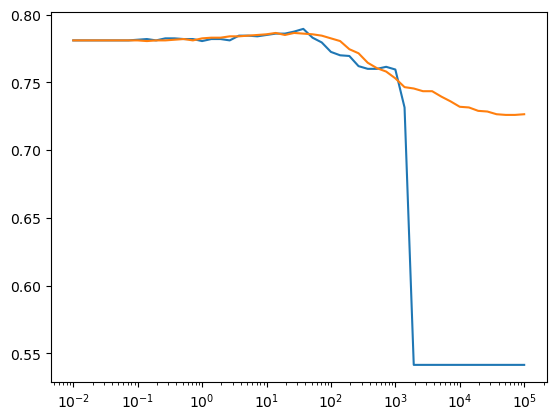

In [14]:
# 1) load the data and normalize it 
x, y = load_dataset()
y = label_to_pm_one(y)
x_train, x_val, y_train, y_val = function_normalize(x, y)

lambda_range = np.logspace(-2, 5, 50)

# 2) compute the scores for logistic regression with l1 penalty
scores_l1 = logistic_l1_crossvalidation(x_train, y_train, x_val, y_val, lambda_range)

# 3) compute the scores for logistic regression with l2 penalty
scores_l2 = logistic_l2_crossvalidation(x_train, y_train, x_val, y_val, lambda_range)

# 4) plot the scores as a function of lambda_range
plt.plot(lambda_range, scores_l1, label='l1')
plt.plot(lambda_range, scores_l2, label='l2')
plt.xscale('log')
plt.show()

# 5) print the best lambda for l1 and l2 penalties
lambda_1_optimal = lambda_range[np.argmax(scores_l1)]
lambda_2_optimal = lambda_range[np.argmax(scores_l2)]

In [21]:
print('Optimal lambda for l1:', lambda_1_optimal, 'with score:', np.max(scores_l1))
print('Optimal lambda for l2:', lambda_2_optimal, 'with score:', np.max(scores_l2))

Optimal lambda for l1: 37.27593720314938 with score: 0.7895
Optimal lambda for l2: 13.894954943731374 with score: 0.7865


d) When $\lambda$ is big enough, the validation accuracy for $\ell_1$ regularization becomes constant to some value (let's call it $acc_{\infty}$). Justify that $acc_{\infty}$ is equal to the proportion of background events (i.e samples with label $-1$) in the validation data.

_Answer_ : 

As seen in class, $L_1$ regularization has a sparsifying effect, meaning that it drives coefficients of $\vec w$ to $0$. When $\lambda$ gets very large, **all** the coefficients of $\vec w$ will be equal strictly to $0$, **including the bias**. Because of this, the prediction function of the model is constant as $\vec w \cdot \vec x = 0$ for all $x$ in the validation data. Note that then the predicted probability for each class $-1$ and $1$ is equal to $0.5$. By looking at the documentation of sklearn [1], in that case by convention the predicted class is $-1$. As a consequence, **all** the predictions will be equal to $-1$, which is the proportion of background events in the validation data. 

[1] https://github.com/scikit-learn/scikit-learn/blob/6e9039160/sklearn/linear_model/_base.py#L367
 

**NOTE** : 
1) The vast majority of the answers justified the accuracy by saying that as the model is constant, the (constant) prediction is the **majority class** in the validation data. This is inacurrate, and a easy way to see how it is wrong is to flip the labels in the data $\tilde y = -y$. With these new labels, one can observe that the majority class is $1$ and yet the accuracy is now around $45\%$

2) To be awarded full points, one needed to mention the sparsifying effect of $L_1$. Indeed, some answers merely mentioned that as $\lambda$ gets large, the coefficients "get close to zero" or "the loss is approximately equal to the regularization". This is inacurrante and does not fully explain the behavior (in particular it does not say why we don't observe the same behavior with the $L_2$ regularization).

3) Some answers missed the fact that the bias is **also** regularized and is driven to zero at large $\lambda$. It is true that if the bias is not regularized, then the prediction will be the majority class in the training data. However, this is not the case here.

### Adding interacting polynomial features

In this section, we will try to improve our classifier by adding features in our data, namely the product of the 18 existing features. That is to say, for all pair of indices $0 \leqslant i, j \leqslant 17$ with $i \neq j$ we will add the feature `X[:, i] * X[:, j]` to the matrix `X` (to have 171 features in total).

**Question 5** Use the class `sklearn.preprocessing.PolynomialFeatures` with the correct arguments `degree` and `interaction_only` to add these features to the data.


In [16]:
def add_interactions(X):
    poly = pp.PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_poly = poly.fit_transform(X)
    return X_poly

**Question 6** Redo the steps of question 3 and 4 to find the optimal regularization strength $\lambda_{1, poly}$ and $\lambda_{2, poly}$ that correspond to the best validation accuracy. Did the validation accuracy improve compared to question 4 ? 

_NOTE_ : The computation may take some time, so be patient.

_Answer_ : ...

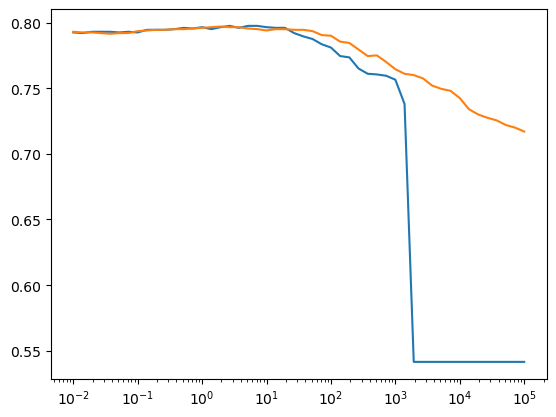

In [17]:
x_poly = add_interactions(x)
x_train_poly, x_val_poly, y_train_poly, y_val_poly = function_normalize(x_poly, y)

scores_l1_poly = logistic_l1_crossvalidation(x_train_poly, y_train_poly, x_val_poly, y_val_poly, lambda_range)
scores_l2_poly = logistic_l2_crossvalidation(x_train_poly, y_train_poly, x_val_poly, y_val_poly, lambda_range)

plt.plot(lambda_range, scores_l1_poly, label='l1')
plt.plot(lambda_range, scores_l2_poly, label='l2')
plt.xscale('log')
plt.legend()
plt.show()


In [20]:
print("Optimal lambda for l1:", lambda_range[np.argmax(scores_l1_poly)], " score is ", np.max(scores_l1_poly))
print("Optimal lambda for l2:", lambda_range[np.argmax(scores_l2_poly)], " score is ", np.max(scores_l2_poly))

Optimal lambda for l1: 2.6826957952797246  score is  0.7975
Optimal lambda for l2: 1.9306977288832496  score is  0.797
